# Brandon Watanabe
## 04-27-2026
## CSC747
Coding Project 4: a single-qubit randomized benchmark to discover the limits of accuracy on a simulator that uses a noise model for one of the IBM Quantum QPUs.


In [1]:
# imports, part 1
import numpy as np
import matplotlib.pyplot as plt
import math
import random

import qiskit
print(f"Qiskit version: {qiskit.__version__}")

Qiskit version: 2.1.2


In [2]:
# imports, part 2

from qiskit_aer import AerSimulator
from qiskit import transpile

sim = AerSimulator()

print(sim)
print(f"\nConfiguration: {sim.configuration()}")

# obtain and print info about available simulation backends
# see https://qiskit.github.io/qiskit-aer/stubs/qiskit_aer.AerSimulator.html#qiskit_aer.AerSimulator

if hasattr(sim, 'available_methods'):
    print(f"Available methods: {sim.available_methods()}")
else:
    print(sim.configuration())

if hasattr(sim, 'available_devices'):
    print(f"Available devices: {sim.available_devices()}")
else:
    print(sim.configuration())   

AerSimulator('aer_simulator')

Configuration: <qiskit_aer.backends.backendconfiguration.AerBackendConfiguration object at 0x0000011714AD47D0>
Available methods: ('automatic', 'statevector', 'density_matrix', 'stabilizer', 'matrix_product_state', 'extended_stabilizer', 'unitary', 'superop')
Available devices: ('CPU',)


In [3]:
from datetime import date
print(date.today())

2026-04-27


In [4]:
# imports, part 3, needed to verify you have all the basic required packages installed
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_distribution, array_to_latex
from qiskit.circuit.library import HGate, XGate, YGate, ZGate
from qiskit.circuit import Gate

In [5]:
# helper function needed to use plot_bloch_vector() method: converts statevector to 3 values
def statevector_to_bloch_vector(state):
    bloch_x = 2 * np.real(state[0] * np.conj(state[1]))
    bloch_y = 2 * np.imag(state[1] * np.conj(state[0]))
    bloch_z = np.abs(state[0])**2 - np.abs(state[1])**2
    return [bloch_x, bloch_y, bloch_z]

# helper function to plot two bloch spheres side by side
# inputs are two statevectors and two title strings
def plot_2bloch_spheres(state1, title1, state2, title2):
    fig, axs = plt.subplots(1, 2, figsize=(10, 4), subplot_kw={'projection': '3d'})
    
    plot_bloch_vector(statevector_to_bloch_vector(state1), ax=axs[0])
    axs[0].set_title(title1, pad=20)

    plot_bloch_vector(statevector_to_bloch_vector(state2), ax=axs[1])
    axs[1].set_title(title2, pad=20)

    plt.show()

In [6]:
def run_job(qc, simulator, n_shots = 2**10, do_transpile=False, print_res=True):  
    if do_transpile:
        qc = transpile(qc, simulator,optimization_level=0)

    if print_res:
        display(qc.draw('mpl'))

    job = simulator.run(qc, shots=n_shots)
    result = job.result()
    
    # Get counts and output distribution
    counts = result.get_counts(qc)

    print("Counts:")
    print(counts)
    
    if print_res:
        display(plot_distribution(counts))

    return counts

In [7]:
def display_statevector(qc):
    # Get Statevector
    state = Statevector.from_instruction(qc)

    # Display Statevector
    print("\nStatevector:")
    display(state.draw("latex"))

    matrix_form = np.array(state).reshape(-1, 1)
    print("\nStatevector as a matrix:")
    display(array_to_latex(matrix_form))
    
    # Display the Unitary Matrix
    print("Unitary matrix:")
    display(Operator(qc).draw("latex"))

    return state

### Part 1: Base code implementation

In [8]:
def construct_rand_circ_1(N, gates = [HGate, XGate, YGate, ZGate]):
    qc = QuantumCircuit(1)

    circuit = []

    # initialize to |1> 
    qc.x(0)
    qc.barrier(label="init")

    # construct half the circuit
    for _ in range(N):
        circuit.append(random.choice(gates))

    circuit = circuit + circuit[::-1]

    for i, g in enumerate(circuit):
        qc.append(g(), [0])
        if i == N:
            qc.barrier(label='half')

    return qc


Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

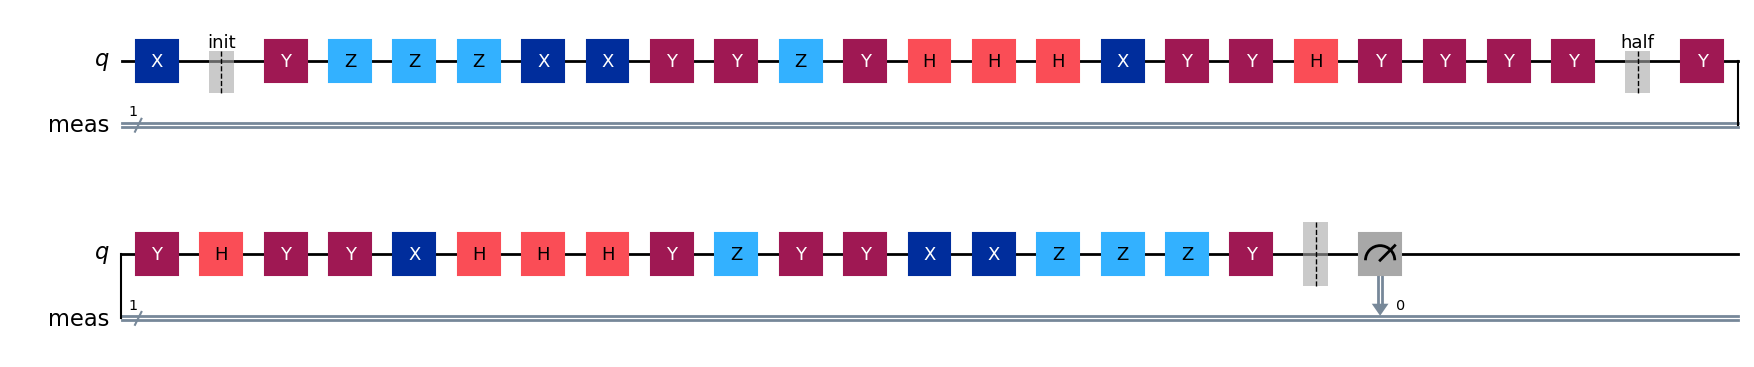

Counts:
{'1': 1024}


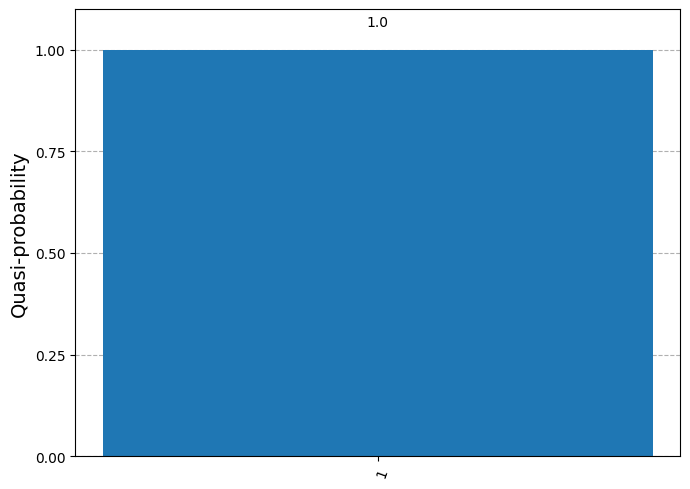

Accuracy: 1.0


In [9]:
qc1 = construct_rand_circ_1(20)

display_statevector(qc1)

qc1.measure_all()

n_shots = 2**10
counts = run_job(qc1, sim, n_shots=n_shots)
accuracy = counts.get('1', 0) / n_shots
print(f"Accuracy: {accuracy}")


### Part 2: Run on a Fake Backend

In [10]:
# FakeCairoV2 native single qubit gates include: x, sx, and rz. 
# https://github.com/Qiskit/qiskit-ibm-runtime/blob/stable/0.46/qiskit_ibm_runtime/fake_provider/backends/cairo/conf_cairo.json

from qiskit_ibm_runtime.fake_provider import FakeCairoV2
backend_cairo = FakeCairoV2()

print("Backend basis gates:")
print(backend_cairo.configuration().basis_gates)

class CairoHGate(Gate):
    def __init__(self):
        super().__init__("h_cairo", 1, [])

    def _define(self):
        qc = QuantumCircuit(1)
        qc.rz(np.pi / 2, 0)
        qc.sx(0)
        qc.rz(np.pi / 2, 0)
        self.definition = qc

class CairoYGate(Gate):
    def __init__(self):
        super().__init__("y_cairo", 1, [])

    def _define(self):
        qc = QuantumCircuit(1)
        qc.rz(np.pi / 2, 0)
        qc.x(0)
        qc.rz(np.pi / 2, 0)
        self.definition = qc

class CairoZGate(Gate):
    def __init__(self):
        super().__init__("z_cairo", 1, [])

    def _define(self):
        qc = QuantumCircuit(1)
        qc.rz(np.pi, 0)
        self.definition = qc


Backend basis gates:
['cx', 'ecr', 'id', 'rz', 'sx', 'x']


Testing CairoHGate

Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

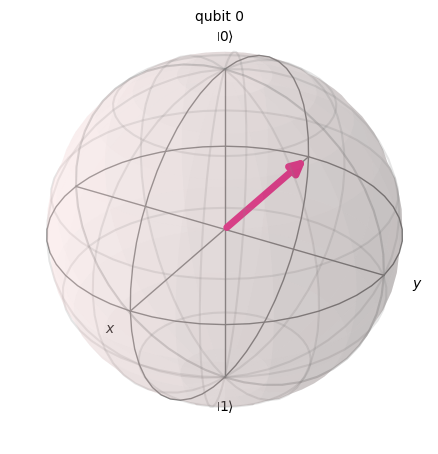

Testing CairoYGate

Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

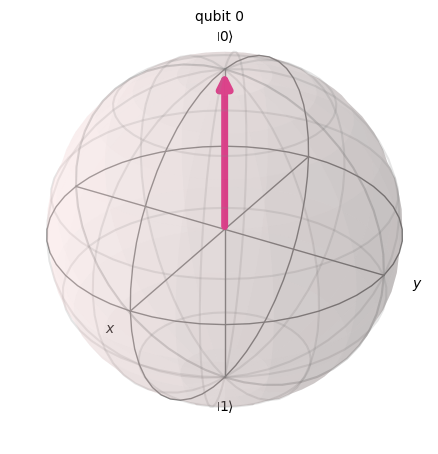

Testing CairoZGate

Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

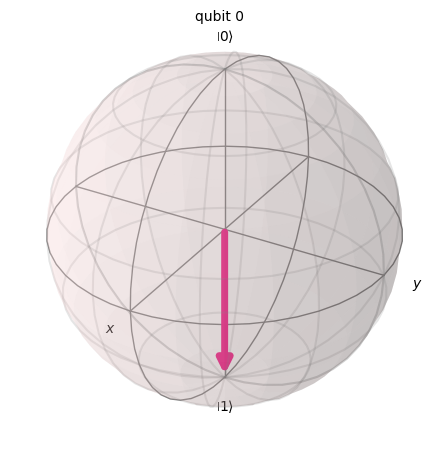

In [11]:
# test each custom gate
print(f"Testing CairoHGate")
qc = QuantumCircuit(1)
qc.x(0)
qc.append(CairoHGate(), [0])
state = display_statevector(qc)
display(plot_bloch_multivector(state))

print(f"Testing CairoYGate")
qc = QuantumCircuit(1)
qc.x(0)
qc.append(CairoYGate(), [0])
state = display_statevector(qc)
display(plot_bloch_multivector(state))

print(f"Testing CairoZGate")
qc = QuantumCircuit(1)
qc.x(0)
qc.append(CairoZGate(), [0])
state = display_statevector(qc)
display(plot_bloch_multivector(state))



Statevector:


<IPython.core.display.Latex object>


Statevector as a matrix:


<IPython.core.display.Latex object>

Unitary matrix:


<IPython.core.display.Latex object>

Circuit Before Transpilation


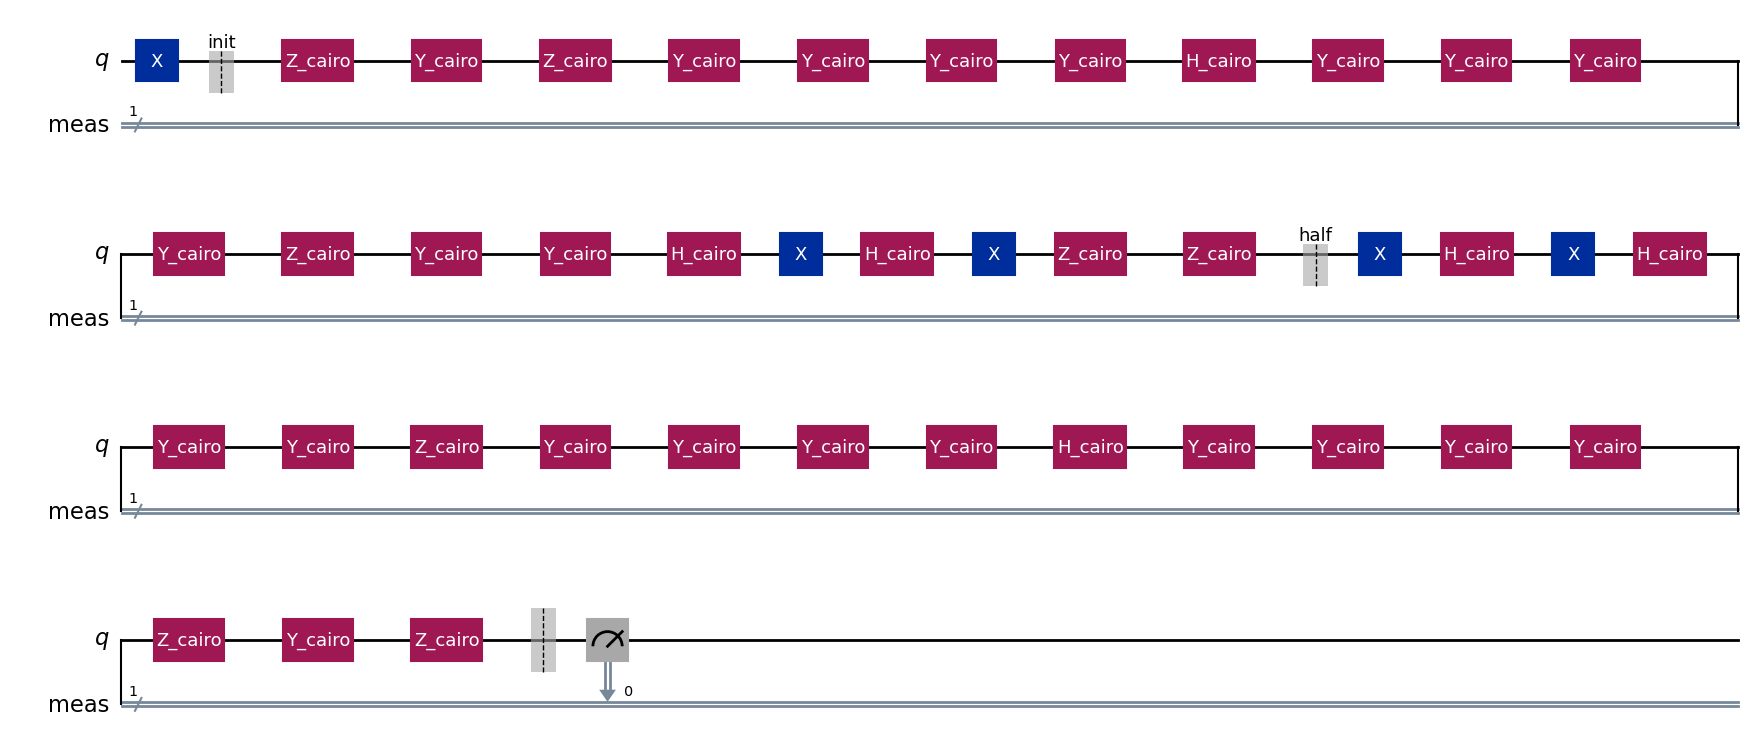

Circuit After Transpilation


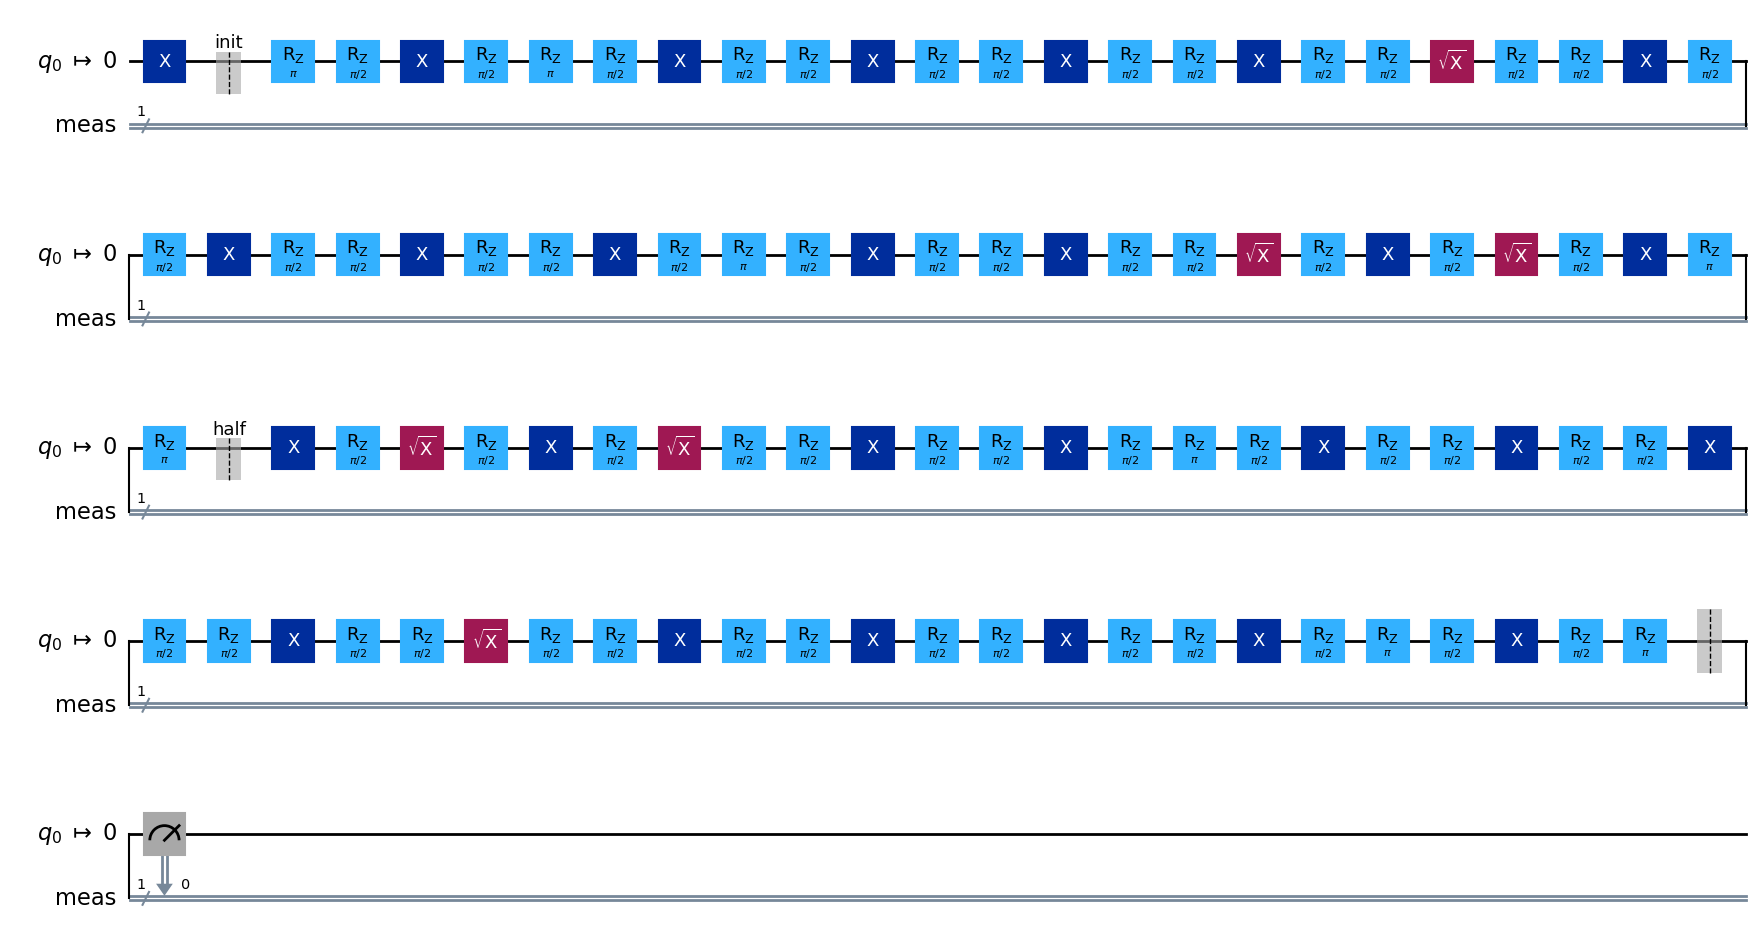

Counts:
{'1': 1001, '0': 23}


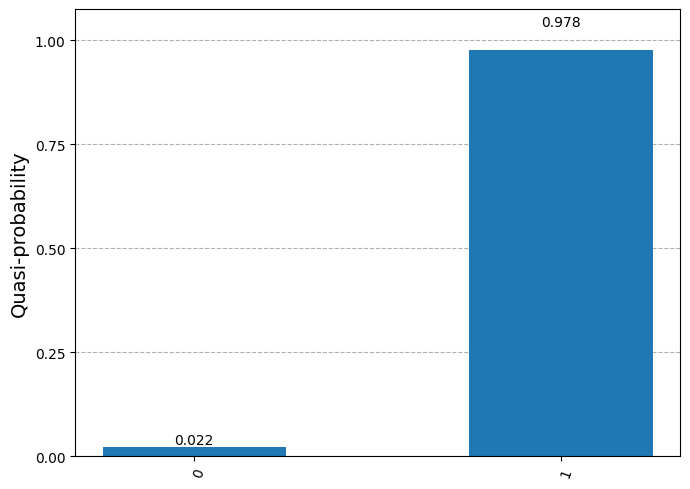

Accuracy: 0.9775390625


In [12]:
cairo_gates = [CairoHGate, XGate, CairoYGate, CairoZGate]

qc2 = construct_rand_circ_1(20, gates=cairo_gates)

display_statevector(qc2)

qc2.measure_all()

print("Circuit Before Transpilation")
display(qc2.draw('mpl'))

n_shots = 2**10
print("Circuit After Transpilation")
counts = run_job(qc2, backend_cairo, do_transpile=True, n_shots=n_shots)
accuracy = counts.get('1', 0) / n_shots
print(f"Accuracy: {accuracy}")

### Part 3: Find the limits for 50% accuracy


n: 100
Counts:
{'1': 965, '0': 59}
Accuracy for 100 gate pairs: 0.9423828125

n: 150
Counts:
{'1': 945, '0': 79}
Accuracy for 150 gate pairs: 0.9228515625

n: 200
Counts:
{'1': 947, '0': 77}
Accuracy for 200 gate pairs: 0.9248046875

n: 250
Counts:
{'1': 910, '0': 114}
Accuracy for 250 gate pairs: 0.888671875

n: 300
Counts:
{'1': 907, '0': 117}
Accuracy for 300 gate pairs: 0.8857421875

n: 350
Counts:
{'0': 132, '1': 892}
Accuracy for 350 gate pairs: 0.87109375

n: 400
Counts:
{'1': 868, '0': 156}
Accuracy for 400 gate pairs: 0.84765625

n: 450
Counts:
{'0': 175, '1': 849}
Accuracy for 450 gate pairs: 0.8291015625

n: 500
Counts:
{'1': 841, '0': 183}
Accuracy for 500 gate pairs: 0.8212890625

n: 550
Counts:
{'1': 819, '0': 205}
Accuracy for 550 gate pairs: 0.7998046875

n: 600
Counts:
{'1': 814, '0': 210}
Accuracy for 600 gate pairs: 0.794921875

n: 650
Counts:
{'1': 835, '0': 189}
Accuracy for 650 gate pairs: 0.8154296875

n: 700
Counts:
{'1': 786, '0': 238}
Accuracy for 700 gate pa

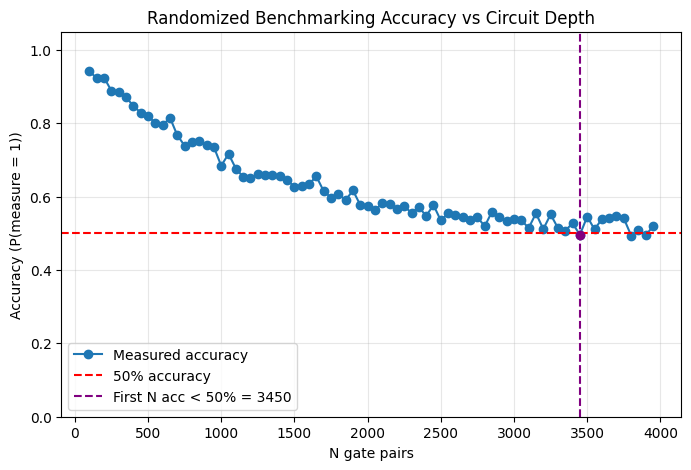

In [13]:
N = 4000
n_shots = 2**10
accuracies = []
depths = list(range(100, N, 50))
first_below_threshold = None

for n in depths:
    print(f"\nn: {n}")
    qc3 = construct_rand_circ_1(n, gates=cairo_gates)

    qc3.measure_all()

    counts = run_job(qc3, backend_cairo, n_shots=n_shots, do_transpile=True, print_res=False)
    accuracy = counts.get('1', 0) / n_shots
    print(f"Accuracy for {n} gate pairs: {accuracy}")

    if accuracy < 0.5 and first_below_threshold is None:
        first_below_threshold = (n, accuracy)
        print(f"Accuracy for {n} gate pairs dropped below 50%: {accuracy}")
    
    accuracies.append(accuracy)

# Plot accuracy
plt.figure(figsize=(8, 5))
plt.plot(depths, accuracies, marker='o', label='Measured accuracy')
plt.axhline(0.5, color='r', linestyle='--', label='50% accuracy')

if first_below_threshold is not None:
    n_drop, a_drop = first_below_threshold
    plt.axvline(n_drop, color='purple', linestyle='--', linewidth=1.5, label=f'First N acc < 50% = {n_drop}')
    plt.scatter([n_drop], [a_drop], color='purple', zorder=5)
else:
    print('Accuracy did not drop below 50% in tested depths.')

plt.xlabel('N gate pairs')
plt.ylabel('Accuracy (P(measure = 1))')
plt.title('Randomized Benchmarking Accuracy vs Circuit Depth')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()